In [ ]:
import dataset_tools as dtools

dtools.download(dataset='FoodSeg103', dst_dir='~/dataset-ninja/')

In [2]:
import os
import json
import base64
import zlib
import numpy as np
import torch
import cv2
from torch.utils.data import Dataset

class FoodSegDataset(Dataset):
    def __init__(self, root_dir, split="train"):
        self.img_dir = os.path.join(root_dir, split, "img")
        self.ann_dir = os.path.join(root_dir, split, "ann")

        self.images = sorted(os.listdir(self.img_dir))

        # Build class mapping from meta.json
        meta = json.load(open(os.path.join(root_dir, "meta.json")))
        self.class_map = {
            cls["title"]: idx + 1
            for idx, cls in enumerate(meta["classes"])
        }

    def __len__(self):
        return len(self.images)

    def decode_bitmap(self, bitmap, height, width):
        data = zlib.decompress(base64.b64decode(bitmap["data"]))
        mask = np.frombuffer(data, dtype=np.uint8)

        origin_x, origin_y = bitmap["origin"]
        small_w = width - origin_x
        small_h = len(mask) // small_w

        small_mask = mask.reshape((small_h, small_w))

        full_mask = np.zeros((height, width), dtype=np.uint8)
        full_mask[
            origin_y:origin_y+small_h,
            origin_x:origin_x+small_w
        ] = small_mask

        return full_mask

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        ann_path = os.path.join(self.ann_dir, img_name + ".json")

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        height, width = img.shape[:2]

        img = torch.tensor(img, dtype=torch.float32).permute(2,0,1) / 255.0

        ann_json = json.load(open(ann_path))

        boxes = []
        labels = []
        masks = []

        for obj in ann_json["objects"]:
            class_name = obj["classTitle"]
            labels.append(self.class_map[class_name])

            mask = self.decode_bitmap(obj["bitmap"], height, width)

            pos = np.where(mask)
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])

            boxes.append([xmin, ymin, xmax, ymax])
            masks.append(mask)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        masks = torch.tensor(np.array(masks), dtype=torch.uint8)

        area = (boxes[:,3] - boxes[:,1]) * (boxes[:,2] - boxes[:,0])
        iscrowd = torch.zeros((len(labels),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": iscrowd
        }

        return img, target

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [4]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.7.1+cu118
11.8


In [6]:
dataset = FoodSegDataset("./FoodSeg", "train")

In [7]:
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn

num_classes = len(dataset.class_map) + 1  # + background

model = maskrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256

model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask,
    hidden_layer,
    num_classes
)

In [9]:
import os
import json
import base64
import zlib
import numpy as np
import cv2
from tqdm import tqdm

INPUT_DIR = "./FoodSeg"
OUTPUT_DIR = "./FoodSeg_COCO"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def decode_bitmap(bitmap):
    data = bitmap["data"]
    origin = bitmap["origin"]

    mask_bytes = zlib.decompress(base64.b64decode(data))
    mask = cv2.imdecode(np.frombuffer(mask_bytes, np.uint8), cv2.IMREAD_UNCHANGED)

    return mask, origin


def mask_to_polygon(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    segmentation = []

    for contour in contours:
        contour = contour.flatten().tolist()
        if len(contour) >= 6:
            segmentation.append(contour)

    return segmentation


def convert_split(split):
    images = []
    annotations = []
    categories = []

    ann_id = 1
    image_id = 1

    meta = json.load(open(os.path.join(INPUT_DIR, "meta.json")))
    class_id_map = {}

    for idx, cls in enumerate(meta["classes"]):
        categories.append({
            "id": idx + 1,
            "name": cls["title"]
        })
        class_id_map[cls["id"]] = idx + 1

    img_dir = os.path.join(INPUT_DIR, split, "img")
    ann_dir = os.path.join(INPUT_DIR, split, "ann")

    for file in tqdm(os.listdir(ann_dir), desc=f"Processing {split}"):
        ann_json = json.load(open(os.path.join(ann_dir, file)))
        filename = file.replace(".json", "")

        height = ann_json["size"]["height"]
        width = ann_json["size"]["width"]

        images.append({
            "id": image_id,
            "file_name": filename,
            "height": height,
            "width": width
        })

        for obj in ann_json["objects"]:
            mask, origin = decode_bitmap(obj["bitmap"])

            full_mask = np.zeros((height, width), dtype=np.uint8)
            y, x = origin[1], origin[0]
            h, w = mask.shape[:2]
            full_mask[y:y+h, x:x+w] = mask[:, :, 3]

            segmentation = mask_to_polygon(full_mask)
            if not segmentation:
                continue

            area = int(np.sum(full_mask > 0))

            ys, xs = np.where(full_mask > 0)
            xmin, xmax = int(xs.min()), int(xs.max())
            ymin, ymax = int(ys.min()), int(ys.max())

            bbox = [xmin, ymin, xmax - xmin, ymax - ymin]

            annotations.append({
                "id": ann_id,
                "image_id": image_id,
                "category_id": class_id_map[obj["classId"]],
                "segmentation": segmentation,
                "area": area,
                "bbox": bbox,
                "iscrowd": 0
            })

            ann_id += 1

        image_id += 1

    coco = {
        "images": images,
        "annotations": annotations,
        "categories": categories
    }

    with open(os.path.join(OUTPUT_DIR, f"{split}.json"), "w") as f:
        json.dump(coco, f)


convert_split("train")
convert_split("test")

Processing test: 100%|██████████| 2135/2135 [00:41<00:00, 51.35it/s] 


In [12]:
import numpy as np
from pycocotools import mask as coco_mask

def format_targets(coco, img_id, annotations, height, width, device):
    boxes = []
    labels = []
    masks = []

    for ann in annotations:
        # ---- BOX ----
        xmin, ymin, w, h = ann["bbox"]
        boxes.append([xmin, ymin, xmin + w, ymin + h])

        # ---- LABEL ----
        labels.append(ann["category_id"])

        # ---- MASK ----
        rles = coco_mask.frPyObjects(ann["segmentation"], height, width)
        rle = coco_mask.merge(rles)
        m = coco_mask.decode(rle)
        masks.append(m)

    if len(boxes) == 0:
        return None

    boxes = torch.tensor(boxes, dtype=torch.float32).to(device)
    labels = torch.tensor(labels, dtype=torch.int64).to(device)
    masks = torch.tensor(np.array(masks), dtype=torch.uint8).to(device)

    return {
        "boxes": boxes,
        "labels": labels,
        "masks": masks
    }

In [13]:
import os
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
from torch.utils.data import DataLoader

# ================= CONFIG =================
TRAIN_JSON = "./FoodSeg_COCO/train.json"
VAL_JSON = "./FoodSeg_COCO/test.json"
TRAIN_IMG = "./FoodSeg/train/img"
VAL_IMG = "./FoodSeg/test/img"

SAVE_DIR = "./checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

EPOCHS = 20
LR = 1e-4
BATCH_SIZE = 2
RESUME = None  # set path if resuming

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================= DATA =================
train_dataset = CocoDetection(TRAIN_IMG, TRAIN_JSON)
val_dataset = CocoDetection(VAL_IMG, VAL_JSON)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# ================= MODEL =================
num_classes = len(train_dataset.coco.cats) + 1  # +1 background
model = maskrcnn_resnet50_fpn(num_classes=num_classes)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

start_epoch = 0
best_val_loss = float("inf")

# ================= RESUME =================
if RESUME:
    checkpoint = torch.load(RESUME)
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]
    print("Resumed from", RESUME)

# ================= TRAINING LOOP =================
for epoch in range(start_epoch, EPOCHS):

    # -------- TRAIN --------
    model.train()
    train_loss = 0

    for images, targets in train_loader:
        images = [F.to_tensor(img).to(device) for img in images]

        formatted_targets = []

        for img, anns in zip(images, targets):
            height, width = img.shape[1], img.shape[2]

            target = format_targets(
                train_dataset.coco,
                None,
                anns,
                height,
                width,
                device
            )

            if target is not None:
                formatted_targets.append(target)

        if len(formatted_targets) == 0:
            continue

        loss_dict = model(images, formatted_targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_loader)

    # -------- VALIDATION --------
    model.train()  # Important: MaskRCNN needs train() for loss
    val_loss = 0

    with torch.no_grad():
        for images, targets in val_loader:
            images = [F.to_tensor(img).to(device) for img in images]

            formatted_targets = []
            for t in targets:
                boxes = []
                labels = []

                for obj in t:
                    boxes.append(obj["bbox"])
                    labels.append(obj["category_id"])

                formatted_targets.append({
                    "boxes": torch.tensor(boxes, dtype=torch.float32).to(device),
                    "labels": torch.tensor(labels, dtype=torch.int64).to(device)
                })

            loss_dict = model(images, formatted_targets)
            loss = sum(loss for loss in loss_dict.values())
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # -------- SAVE LAST --------
    checkpoint = {
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "best_val_loss": best_val_loss
    }

    torch.save(checkpoint, os.path.join(SAVE_DIR, "last.pth"))

    # -------- SAVE BEST --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(checkpoint, os.path.join(SAVE_DIR, "best.pth"))
        print("✅ Saved new BEST model")

print("Training completed.")

loading annotations into memory...
Done (t=2.08s)
creating index...
index created!
loading annotations into memory...
Done (t=0.63s)
creating index...
index created!


AssertionError: All bounding boxes should have positive height and width. Found invalid box [118.6875, 290.30926513671875, 252.2109375, 204.5360870361328] for target at index 0.

In [22]:
import os
import shutil
import numpy as np
from pycocotools.coco import COCO
from tqdm import tqdm

# Paths
COCO_TRAIN_JSON = "./FoodSeg_COCO/train.json"
COCO_TEST_JSON  = "./FoodSeg_COCO/test.json"

TRAIN_IMG_ROOT = "./FoodSeg/train/img"
TEST_IMG_ROOT  = "./FoodSeg/test/img"

OUTPUT_ROOT = "./FoodSeg_YOLO"

# Create YOLO folder structure
for split in ["train", "val"]:
    os.makedirs(os.path.join(OUTPUT_ROOT, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_ROOT, split, "labels"), exist_ok=True)


def convert_split(coco_json_path, image_root, split_name):
    coco = COCO(coco_json_path)

    img_ids = coco.getImgIds()

    for img_id in tqdm(img_ids, desc=f"Processing {split_name}"):
        img = coco.loadImgs(img_id)[0]
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        h, w = img["height"], img["width"]
        file_name = img["file_name"]

        # Copy image
        src_img_path = os.path.join(image_root, file_name)
        dst_img_path = os.path.join(OUTPUT_ROOT, split_name, "images", file_name)
        shutil.copy(src_img_path, dst_img_path)

        # Create label file
        label_path = os.path.join(
            OUTPUT_ROOT,
            split_name,
            "labels",
            file_name.replace(".jpg", ".txt")
        )

        with open(label_path, "w") as f:
            for ann in anns:
                class_id = ann["category_id"] - 1  # must start from 0

                if "segmentation" not in ann:
                    continue

                for seg in ann["segmentation"]:
                    if len(seg) < 6:
                        continue

                    seg = np.array(seg, dtype=np.float32).reshape(-1, 2)

                    # Normalize
                    seg[:, 0] /= w
                    seg[:, 1] /= h

                    seg = seg.flatten().tolist()

                    line = f"{class_id} " + " ".join(map(str, seg))
                    f.write(line + "\n")


# Convert train → train
convert_split(COCO_TRAIN_JSON, TRAIN_IMG_ROOT, "train")

# Convert test → val
convert_split(COCO_TEST_JSON, TEST_IMG_ROOT, "val")

print("✅ Conversion complete.")

loading annotations into memory...
Done (t=1.86s)
creating index...
index created!


Processing train: 100%|██████████| 4983/4983 [00:21<00:00, 236.94it/s]


loading annotations into memory...
Done (t=0.62s)
creating index...
index created!


Processing val: 100%|██████████| 2135/2135 [00:07<00:00, 269.74it/s]

✅ Conversion complete.


In [34]:
import os
import glob
from collections import Counter

# Path to labels folder (train or val)
labels_path = ".\\FoodSeg_YOLO\\train\\labels"   # change accordingly

label_files = glob.glob(os.path.join(labels_path, "*.txt"))

print(os.path.exists(labels_path))
class_counts = Counter()

for file in label_files:
    with open(file, "r") as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

# Map class IDs to names
for class_id, count in class_counts.items():
    print(f"{model.names[class_id]}: {count}")

True
walnut: 1111
pumpkin: 629
cilantro mint: 96
white radish: 1066
seaweed: 1000
avocado: 547
pizza: 696
wine: 1618
potato: 490
tea: 1379
chocolate: 312
milkshake: 943
onion: 942
lemon: 337
oyster mushroom: 190
king oyster mushroom: 1376
egg: 1025
carrot: 360
date: 402
dried cranberries: 437
cherry: 305
pepper: 718
kelp: 610
melon: 232
cheese butter: 345
pear: 189
steak: 855
crab: 711
pineapple: 141
peach: 324
sauce: 608
bamboo shoots: 73
bean sprouts: 281
pork: 151
eggplant: 530
wonton dumplings: 217
red beans: 233
rape: 108
egg tart: 190
pudding: 156
hanamaki baozi: 277
cashew: 233
cake: 554
ginger: 58
bread: 298
snow peas: 78
shrimp: 47
fig: 207
fried meat: 64
celery stick: 202
cauliflower: 71
biscuit: 96
watermelon: 22
peanut: 151
juice: 475
cucumber: 12
kiwi: 185
pasta: 11
garlic: 195
lamb: 83
apple: 136
coffee: 138
soup: 99
rice: 132
white button mushroom: 55
green beans: 29
grape: 25
salad: 117
soy: 463
broccoli: 182
fish: 75
okra: 107
noodles: 155
tofu: 51
lettuce: 44
enoki mu

In [35]:
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1])

for class_id, count in sorted_counts:
    print(f"{model.names[class_id]}: {count}")

chicken duck: 4
spring onion: 5
orange: 7
raspberry: 8
popcorn: 8
mango: 9
other ingredients: 10
pasta: 11
cucumber: 12
sausage: 12
banana: 14
pie: 16
asparagus: 16
apricot: 19
watermelon: 22
grape: 25
green beans: 29
ice cream: 33
blueberry: 33
corn: 33
tomato: 34
cabbage: 38
french fries: 39
shellfish: 40
almond: 43
lettuce: 44
shrimp: 47
tofu: 51
olives: 51
white button mushroom: 55
milk: 56
ginger: 58
fried meat: 64
enoki mushroom: 65
cauliflower: 71
bamboo shoots: 73
fish: 75
snow peas: 78
strawberry: 79
lamb: 83
hamburg: 93
cilantro mint: 96
biscuit: 96
soup: 99
shiitake: 99
french beans: 105
okra: 107
rape: 108
salad: 117
rice: 132
apple: 136
coffee: 138
pineapple: 141
pork: 151
peanut: 151
noodles: 155
pudding: 156
broccoli: 182
kiwi: 185
pear: 189
oyster mushroom: 190
egg tart: 190
garlic: 195
celery stick: 202
fig: 207
wonton dumplings: 217
melon: 232
red beans: 233
cashew: 233
candy: 266
hanamaki baozi: 277
bean sprouts: 281
bread: 298
cherry: 305
chocolate: 312
peach: 324
l

In [38]:
%matplotlib inline

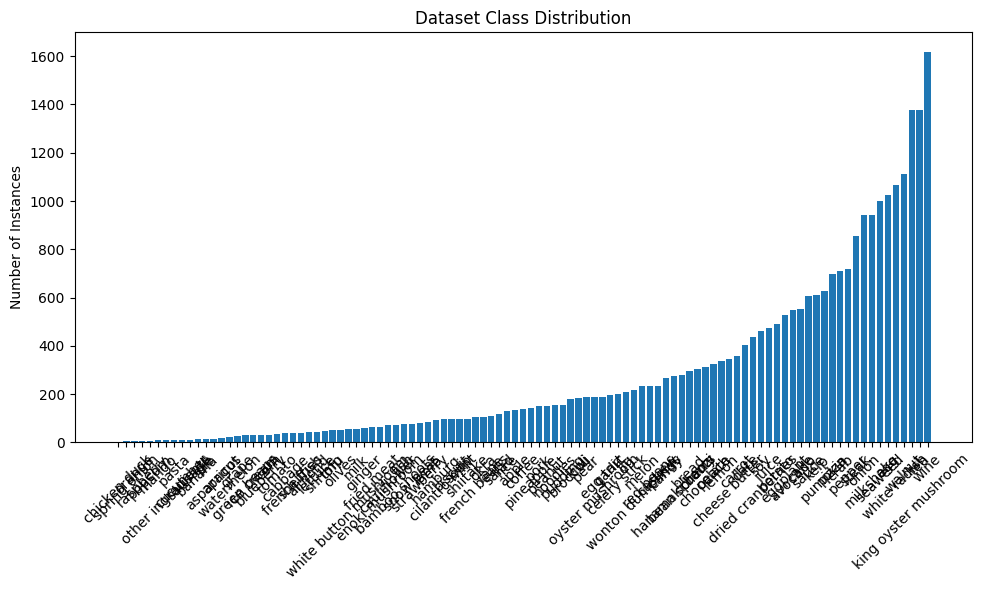

In [39]:
import matplotlib.pyplot as plt
import numpy as np

classes = []
counts = []

for class_id, count in sorted_counts:
    classes.append(model.names[class_id])
    counts.append(count)

plt.figure(figsize=(10,6))
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.ylabel("Number of Instances")
plt.title("Dataset Class Distribution")
plt.tight_layout()
plt.show()

In [ ]:
import json
import yaml
import os

# Paths
META_PATH = "./FoodSeg/meta.json"
OUTPUT_YAML = "./FoodSeg_YOLO/foodseg.yaml"
DATASET_ROOT = "./FoodSeg_YOLO"

# Load meta.json
with open(META_PATH, "r") as f:
    meta = json.load(f)

# Extract classes
# Sort by class ID to ensure stable ordering
classes = sorted(meta["classes"], key=lambda x: x["id"])
class_names = [cls["title"] for cls in classes]

# Build YAML dictionary
data_yaml = {
    "path": DATASET_ROOT,
    "train": "images/train",
    "val": "images/test",   # change if you have separate val
    "nc": len(class_names),
    "names": class_names
}

# Ensure directory exists
os.makedirs(os.path.dirname(OUTPUT_YAML), exist_ok=True)

# Write YAML file
with open(OUTPUT_YAML, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("YAML file created at:", OUTPUT_YAML)
print("Number of classes:", len(class_names))

YAML file created at: ./FoodSeg_YOLO/foodseg.yaml
Number of classes: 103


In [25]:
from ultralytics import YOLO

model = YOLO("yolov8m-seg.pt")

model.train(
    data="./FoodSeg_YOLO/foodseg.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    patience=5,        
    verbose=True
)

Ultralytics 8.4.18  Python-3.12.12 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./FoodSeg_YOLO/foodseg.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\ultralytics\nn\modules\block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\ultralytics\nn\modules\block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDet

train: Fast image access  (ping: 0.00.0 ms, read: 877.0730.7 MB/s, size: 193.1 KB)
train: Scanning C:\Users\ASUS\Documents\Study\Major\Project\Segmentation\FoodSeg_YOLO\train\labels.cache... 4983 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4983/4983  0.0s
val: Fast image access  (ping: 0.10.0 ms, read: 223.4207.5 MB/s, size: 73.1 KB)
val: Scanning C:\Users\ASUS\Documents\Study\Major\Project\Segmentation\FoodSeg_YOLO\val\labels... 2135 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2135/2135 464.7it/s 4.6s0.0s
val: New cache created: C:\Users\ASUS\Documents\Study\Major\Project\Segmentation\FoodSeg_YOLO\val\labels.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=9.3e-05, momentum=0.9) with parameter groups 86 weight(decay=0.0), 97 weight(decay=0.0005), 96 bias(decay=0.0)
Plotting labels to C:\Users\ASUS\Documents\Study\ResumeForge\runs\segment\train6\

c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\ultralytics\utils\loss.py:384: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))
c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\torch\functional.py:422: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(T

      1/100      8.37G     0.8387        2.9       5.13      1.368          0         67        640: 0% ──────────── 0/623  1.1s

...

c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\ultralytics\utils\ops.py:495: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  masks = (masks_in @ protos.float().view(c, -1)).view(-1, mh, mw)  # NHW
c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\ultralytics\utils\metrics.py:163: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::C

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 134/134 2.2it/s 1:00<0.4ss
                   all       2135      12011       0.47      0.335      0.332      0.278      0.457      0.347      0.334      0.263

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size


c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\ultralytics\utils\loss.py:384: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))
c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\torch\functional.py:422: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(T

     30/100      4.89G     0.5319     0.9943       1.08          1          0         93        640: 51% ━━━━━━────── 319/623 3.4it/s 1:54<1:286


KeyboardInterrupt: 

In [28]:
metrics = model.val(data=".\FoodSeg_YOLO\\foodseg.yaml")

print(metrics)

Ultralytics 8.4.18  Python-3.12.12 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 519.4523.0 MB/s, size: 46.6 KB)
val: Scanning C:\Users\ASUS\Documents\Study\Major\Project\Segmentation\FoodSeg_YOLO\val\labels.cache... 2135 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2135/2135  0.0s


<>:1: SyntaxWarning: invalid escape sequence '\F'
<>:1: SyntaxWarning: invalid escape sequence '\F'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_45788\1831239764.py:1: SyntaxWarning: invalid escape sequence '\F'
  metrics = model.val(data=".\FoodSeg_YOLO\\foodseg.yaml")


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 1% ──────────── 1/134 3.3s/it 1.0s<7:23

c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\ultralytics\utils\ops.py:495: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  masks = (masks_in @ protos.float().view(c, -1)).view(-1, mh, mw)  # NHW
c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\ultralytics\utils\metrics.py:163: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::C

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 134/134 2.2s/it 5:010.5ss
                   all       2135      12011       0.46      0.351      0.336      0.282      0.461      0.353      0.338      0.266
                 candy         24         68      0.325      0.338      0.304      0.249      0.325      0.338      0.298      0.227
              egg tart         51         78      0.337        0.5      0.353      0.326      0.337        0.5      0.366      0.307
          french fries          8         18       0.07     0.0556     0.0393     0.0355       0.07     0.0556     0.0422     0.0342
             chocolate         77        130      0.398      0.669      0.533      0.453      0.393      0.662      0.528      0.402
               biscuit         24         33      0.237      0.152      0.126      0.109      0.237      0.152      0.123      0.095
               popcorn  

In [ ]:
results = model.predict(
    source=r"images.jpg",
    imgsz=640,
    conf=0.25,
    save=True,
    show=True
    
)

c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\ultralytics\utils\ops.py:495: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  masks = (masks_in @ protos.float().view(c, -1)).view(-1, mh, mw)  # NHW


image 1/1 c:\Users\ASUS\Documents\Study\Major\Project\Segmentation\images.jpg: 640x416 1 sauce, 1 pizza, 131.3ms
Speed: 4.8ms preprocess, 131.3ms inference, 14.0ms postprocess per image at shape (1, 3, 640, 416)
Results saved to C:\Users\ASUS\Documents\Study\ResumeForge\runs\segment\predict


: 

In [30]:
results = model.predict(
    source=r"images2.jpg",
    imgsz=640,
    conf=0.25,
    save=True,
    show=True
    
)


image 1/1 c:\Users\ASUS\Documents\Study\Major\Project\Segmentation\images2.jpg: 384x640 1 chocolate, 1 wine, 2 teas, 1 pizza, 115.3ms
Speed: 4.3ms preprocess, 115.3ms inference, 23.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\ASUS\Documents\Study\ResumeForge\runs\segment\predict
